In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.2f}'.format #para os números aparecerem com duas casas decimais
pd.set_option('display.max_columns', 50) #mostra 50 colunas ou o número desejado
pd.set_option('future.no_silent_downcasting', True)


In [3]:
dados = pd.read_excel('denuncias-2023-2025.xlsx')
dados

,protocolo,data,tipo_de_violência_denunciada,bairro_da_vítima,regiao_cras,faixa_etária,raça/cor,sexo,vínculo_do_suspeito,ano
0,2068483.00,2023-09-25,Negligência,Distrito de Floriano,Itaipu,70 a 74,Parda,Masculino,Filha(o),2023
1,2060572.00,2023-09-21,Física,Centro,Mandacaru,60 a 64,Parda,Feminino,Não informado,2023
2,2060572.00,2023-09-21,Psicológica,Centro,Mandacaru,60 a 64,Parda,Feminino,Não informado,2023
3,3074201.00,2024-10-07,Física,Centro,Mandacaru,75 a 79,Parda,Feminino,Instituição Privada,2024
4,3074201.00,2024-10-07,Negligência,Centro,Mandacaru,75 a 79,Parda,Feminino,Instituição Privada,2024
...,...,...,...,...,...,...,...,...,...,...
1002,4190066.00,2025-12-30,Psíquica,Zona 07,Mandacaru,70 a 74,Branca,Feminino,Desconhecido(a),2025
1003,2089157.00,2023-10-03,Física,Zona 08,Mandacaru,65 a 69,Branca,Feminino,Filha(o),2023
1004,2612888.00,2024-05-14,Negligência,Zona 08,Mandacaru,60 a 64,Branca,Masculino,Irmã(o),2024
1005,2053146.00,2023-09-18,Psicológica,Zona 20,Mandacaru,65 a 69,Parda,Feminino,Companheiro(a),2023


In [4]:
df_agrupado = dados.groupby('regiao_cras')['tipo_de_violência_denunciada'].size().sort_values(ascending=True)
df_agrupado

regiao_cras
Iguatemi              8
Santa Clara          19
Não Informado        21
São Judas Tadeu      33
Requião              71
Santa Felicidade     72
Itaipu               79
Branca Vieira        92
Ney Braga            96
Alvorada            115
Morangueira         160
Mandacaru           241
Name: tipo_de_violência_denunciada, dtype: int64

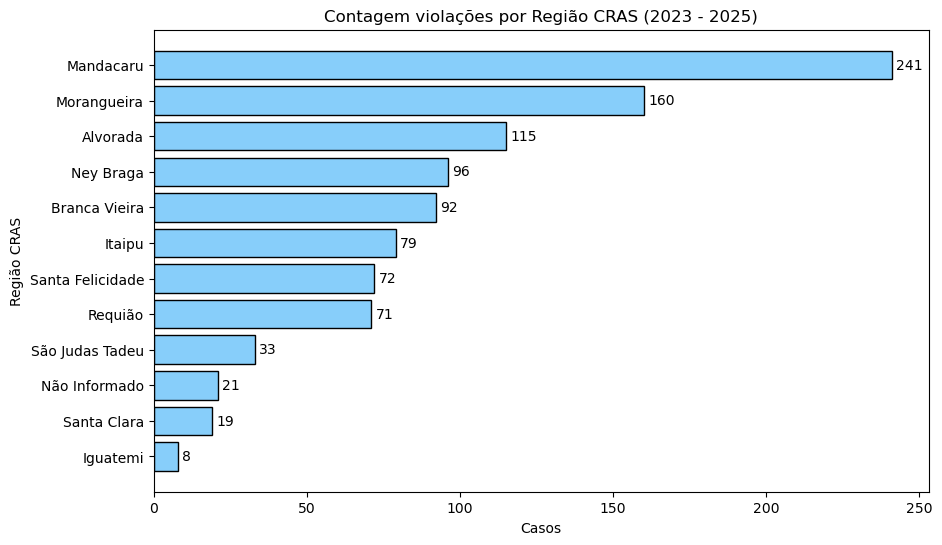

In [5]:
eixo_y = df_agrupado.index
eixo_x = df_agrupado.values

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(eixo_y, eixo_x, edgecolor='black', color = 'lightskyblue')
ax.set_title('Contagem violações por Região CRAS (2023 - 2025)')
ax.set_xlabel('Casos')
ax.set_ylabel('Região CRAS')
ax.bar_label(ax.containers[0], padding = 3)
fig.savefig('violacoes-regiao-cras.png', dpi=300, bbox_inches='tight')

In [11]:
df_agrupado2 = dados.groupby('vínculo_do_suspeito')['regiao_cras'].size().sort_values(ascending=True)
df_agrupado2

vínculo_do_suspeito
Amigo                        1
Síndico                      1
Não Possui                   1
Amante do Companheiro        2
Desconhecido(a)              2
Ex-Companheiro               2
Vizinho                      2
Ex-Companheira               3
Instituição clandestina      3
Dono Pensionato              4
Não se aplica;               4
Outros                       5
Inquilinas                   5
Cuidadora                    8
Empregador                  11
Vizinhos                    13
Instituição Pública         34
Não informado               40
Neto(a)                     43
Companheiro(a)              51
Irmã(o)                     58
Instituição Privada         60
Familiar                    77
Filha(o)                   577
Name: regiao_cras, dtype: int64

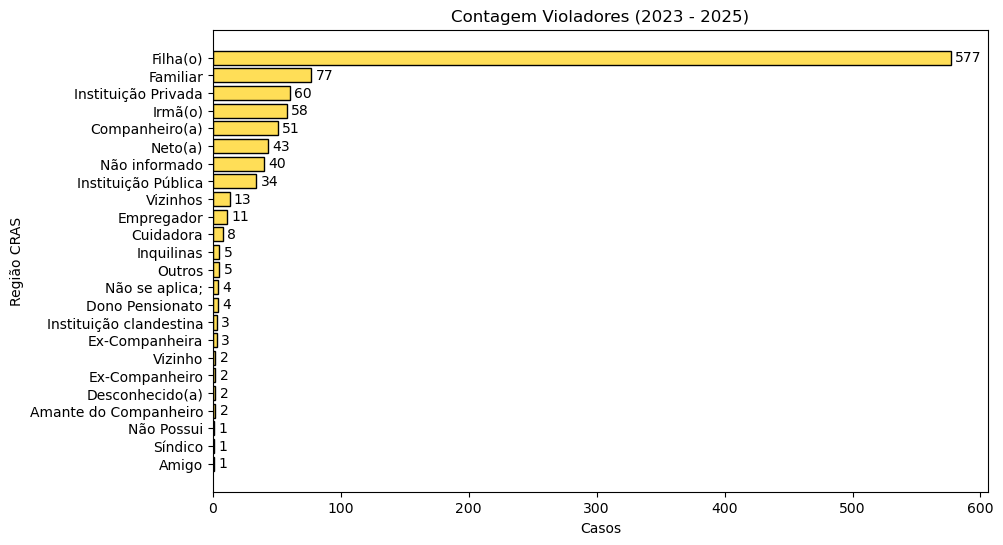

In [14]:
eixo_y = df_agrupado2.index
eixo_x = df_agrupado2.values

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(eixo_y, eixo_x, edgecolor='black', color = '#ffde57')
ax.set_title('Contagem Violadores (2023 - 2025)')
ax.set_xlabel('Casos')
ax.set_ylabel('Região CRAS')
ax.bar_label(ax.containers[0], padding = 3)
fig.savefig('violadores.png', dpi=300, bbox_inches='tight')